In [41]:
# ── Dependency Guard ───────────────────────────────────────────────
import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
from scipy.stats import pearsonr, spearmanr, contingency

All required packages already installed ✓


In [42]:
# ── Reproducibility Header ────────────────────────────────────────────

import sys, random
import numpy as np
import warnings
import requests

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')

Python  : 3.12.3
NumPy   : 2.4.3
Seed    : 414


In [57]:
def get_season_results(year: int) -> pd.DataFrame:
    
    offset = 0
    limit = 100
    rows = []

    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{year}/results.json?limit={limit}&offset={offset}"
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        data = response.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']

        for race in races:
            for result in race['Results']:
                rows.append({
                    'season': int(race['season']),
                    'round': int(race['round']),
                    'race_name': race['raceName'],
                    'circuit': race['Circuit']['circuitId'],
                    'date': race['date'],
                    'driver': result['Driver']['driverId'],
                    'driver_name': f"{result['Driver']['givenName']} {result['Driver']['familyName']}",
                    'constructor': result['Constructor']['constructorId'],
                    'grid': int(result['grid']),
                    'position': int(result['position']) if result['position'].isdigit() else None,
                    'points': float(result['points']),
                    'status': result['status'],
                    'laps': int(result['laps']),
                })

        offset += limit

        if offset >= total:
            break

    return pd.DataFrame(rows)

seasons = [2023, 2024]
dfs = []

for year in seasons:
    df_year = get_season_results(year)
    print(f"{year}: {len(df_year)} rows, {df_year['round'].nunique()} races")
    dfs.append(df_year)

df = pd.concat(dfs, ignore_index=True)
df['date'] = pd.to_datetime(df['date'])
df['top10'] = (df['position'] <= 10)

2023: 440 rows, 22 races
2024: 479 rows, 24 races


In [58]:
df

,season,round,race_name,circuit,date,driver,driver_name,constructor,grid,position,points,status,laps,top10
0,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,max_verstappen,Max Verstappen,red_bull,1,1,25.0,Finished,57,True
1,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,perez,Sergio Pérez,red_bull,2,2,18.0,Finished,57,True
2,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,alonso,Fernando Alonso,aston_martin,5,3,15.0,Finished,57,True
3,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,sainz,Carlos Sainz,ferrari,4,4,12.0,Finished,57,True
4,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,hamilton,Lewis Hamilton,mercedes,7,5,10.0,Finished,57,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,kevin_magnussen,Kevin Magnussen,haas,14,16,0.0,Lapped,57,False
915,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,lawson,Liam Lawson,rb,12,17,0.0,Retired,55,False
916,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,bottas,Valtteri Bottas,sauber,9,18,0.0,Retired,30,False
917,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,colapinto,Franco Colapinto,williams,20,19,0.0,Retired,26,False


# Data Quality Audit

In [59]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   season       919 non-null    int64         
 1   round        919 non-null    int64         
 2   race_name    919 non-null    object        
 3   circuit      919 non-null    object        
 4   date         919 non-null    datetime64[ns]
 5   driver       919 non-null    object        
 6   driver_name  919 non-null    object        
 7   constructor  919 non-null    object        
 8   grid         919 non-null    int64         
 9   position     919 non-null    int64         
 10  points       919 non-null    float64       
 11  status       919 non-null    object        
 12  laps         919 non-null    int64         
 13  top10        919 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(5), object(6)
memory usage: 94.4+ KB


season         0
round          0
race_name      0
circuit        0
date           0
driver         0
driver_name    0
constructor    0
grid           0
position       0
points         0
status         0
laps           0
top10          0
dtype: int64

## Missing Values

position  
Puede ser nulo si el piloto no clasifica con posición numérica (ej. DNF o DSQ).  
Clasificación: MNAR.

grid  
Puede ser 0 si el piloto parte desde pitlane.  
Clasificación: MAR.

laps  
Puede ser menor al máximo cuando el piloto abandona.

## Data Types

Numéricas:
- grid
- position
- points
- laps
- round

Categóricas:
- driver
- constructor
- circuit
- status

Temporales:
- date

## Outliers

Valores bajos de laps pueden indicar abandono temprano.

## Temporal Availability

Pre-race:
- driver
- constructor
- circuit
- grid

Post-race:
- position
- points
- status
- laps

## Question 1
¿La posición de salida influye en terminar dentro del Top-10?

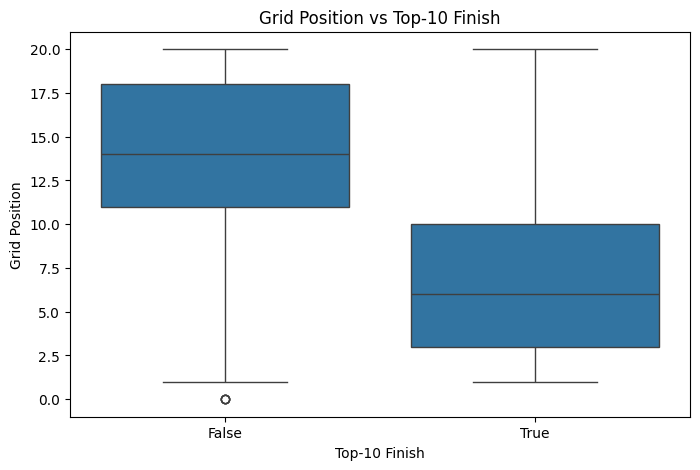

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="top10", y="grid")
plt.title("Grid Position vs Top-10 Finish")
plt.xlabel("Top-10 Finish")
plt.ylabel("Grid Position")
plt.show()

### Interpretation

Los pilotos que terminan en Top-10 tienden a partir desde posiciones significativamente más adelantadas.

### Decision

La variable **grid** es un predictor importante para modelos que intenten anticipar resultados de carrera.

## Question 2
¿El dataset está balanceado respecto al target Top-10?

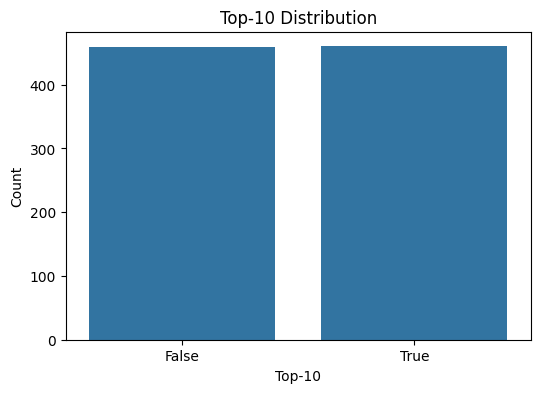

season  round  race_name             circuit     date        driver          driver_name      constructor   grid  position  points  status    laps  top10
2023    1      Bahrain Grand Prix    bahrain     2023-03-05  albon           Alexander Albon  williams      15    10        1.0     Finished  57    True     1
                                                             alonso          Fernando Alonso  aston_martin  5     3         15.0    Finished  57    True     1
                                                             bottas          Valtteri Bottas  alfa          12    8         4.0     Finished  57    True     1
                                                             gasly           Pierre Gasly     alpine        20    9         2.0     Finished  57    True     1
                                                             hamilton        Lewis Hamilton   mercedes      7     5         10.0    Finished  57    True     1
                                                   

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='top10')
plt.title("Top-10 Distribution")
plt.xlabel("Top-10")
plt.ylabel("Count")
plt.show()

print(df[df['position'] <= 10].value_counts())
print(df[df['position'] > 10].value_counts())

### Interpretation

Cada carrera tiene aproximadamente 10 pilotos dentro del Top-10 y el resto fuera de él, generando una distribución cercana al 50%.

Si un modelo siempre predijera la clase mayoritaria, su desempeño sería limitado.

### Decision

Se deben evaluar métricas adicionales a accuracy, como F1 o ROC-AUC.

## Question 3
¿La distribución del Top-10 cambia entre las temporadas 2023 y 2024?

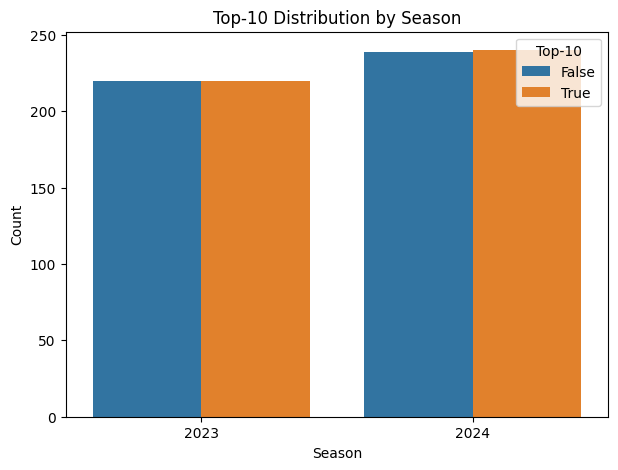

In [62]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="season", hue='top10')
plt.title("Top-10 Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(title="Top-10")
plt.show()

### Interpretation

La proporción de pilotos que terminan en Top-10 se mantiene relativamente estable entre temporadas.

### Decision

Los modelos entrenados en una temporada pueden generalizar razonablemente a la siguiente.

## Question 4
¿Algunos constructores tienen mayor probabilidad de terminar en Top-10?

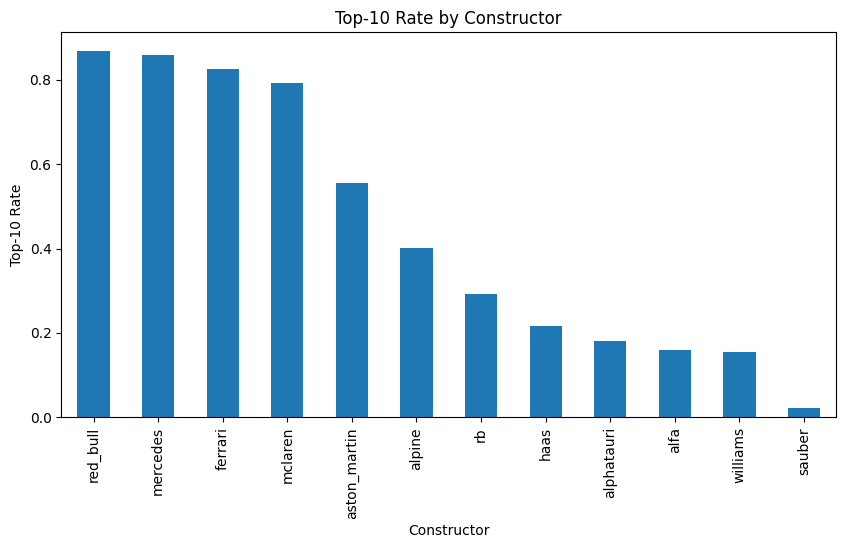

In [63]:
team_top10 = df.groupby("constructor")["top10"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
team_top10.plot(kind="bar")
plt.title("Top-10 Rate by Constructor")
plt.xlabel("Constructor")
plt.ylabel("Top-10 Rate")
plt.show()

### Interpretation

Algunos equipos muestran tasas significativamente más altas de Top-10, lo que refleja diferencias de rendimiento entre constructores.

### Decision

La variable **constructor** debe incluirse como feature categórica en modelos predictivos.

## Question 5
¿Qué variables numéricas se correlacionan con terminar en Top-10?

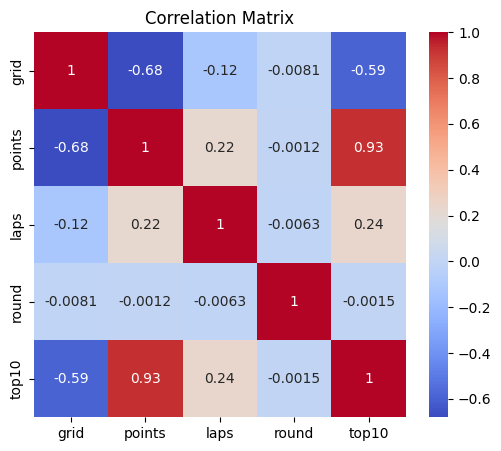

In [64]:
features = ["grid", "points", "laps", "round"]

corr = df[features + ["top10"]].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Interpretation

Grid presenta correlación negativa con Top-10: posiciones de salida más adelantadas aumentan la probabilidad de terminar en el Top-10.

Points presenta correlación positiva fuerte, pero es una variable post-carrera.

### Decision

Para predicción previa a la carrera se deben utilizar principalmente variables disponibles antes del evento.

## Trap Check: Survivorship Bias

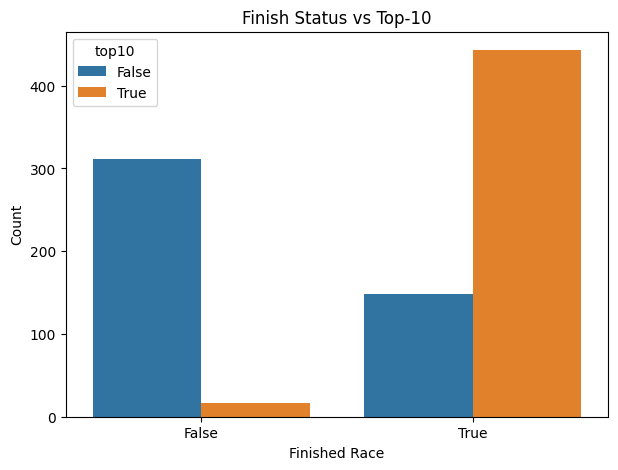

In [65]:
df["finished"] = df["status"] == "Finished"

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="finished", hue="top10")
plt.title("Finish Status vs Top-10")
plt.xlabel("Finished Race")
plt.ylabel("Count")
plt.show()

### Interpretation

Los pilotos que no terminan la carrera no pueden obtener un Top-10.

Excluir estos registros generaría **survivorship bias**, ya que el dataset solo incluiría pilotos exitosos.

### Decision

Los abandonos deben mantenerse en el dataset para evitar sesgos.

## Temporal Train / Validation / Test Split

In [66]:
train = df[df["season"] == 2023]

val = df[(df["season"] == 2024) & (df["round"] <= 10)]

test = df[(df["season"] == 2024) & (df["round"] > 10)]

len(train), len(val), len(test)

(440, 199, 280)

### Rationale

Train: temporada 2023  
Validation: primeras carreras de 2024  
Test: últimas carreras de 2024

Esto respeta el orden temporal y evita data leakage.

# 1-3-1 Summary

**1 Insight**

La posición de salida es el predictor pre-carrera más fuerte para terminar en el Top-10.

**3 Supporting Points**

- Existe correlación negativa clara entre grid y Top-10.
- La distribución del target es consistente entre temporadas.
- Algunos constructores tienen probabilidades significativamente mayores de terminar en Top-10.

**1 Decision**

Los modelos predictivos deben centrarse en variables disponibles antes de la carrera, especialmente grid position y constructor.